# Chapter 5 — Bounded Confidence and Negative Influence
**Modeling Social Behavior** | Smaldino

---

### What this notebook does

This notebook builds on the positive influence model from Exercise 5.2 by adding
two new mechanisms both controlled by a single parameter `d` (confidence threshold):

**Bounded Confidence (Section 5.3)**  
Agents only influence each other when they are sufficiently similar. If $|x_1 - x_2| < d$,
they apply the positive influence update (Equation 5.1). Otherwise, nothing happens.
This breaks the inevitability of consensus and allows stable opinion **cliques** to form.

**Negative Influence / Repulsion (Section 5.4)**  
Instead of ignoring each other when opinions differ too much, agents are actively
*pushed apart*. If $|x_1 - x_2| \geq d$ and repulsion is enabled, both agents move
further from each other toward the nearest extreme (Equation 5.3).
This produces inevitable **polarization**.

### Model toggles (matching the original)

| Toggle | Off | On |
|---|---|---|
| `spatial_interactions` | Any agent can interact with any other (well-mixed) | Agents interact only with their 4 grid neighbors |
| `repulsion` | BC model: ignore sufficiently different agents | Negative influence: push sufficiently different agents apart |

### Experiment included
We replicate the batch experiment from the book (Figure 5.4A): running 30 simulations
per confidence threshold value and plotting the number of emergent cliques as a function
of `d`.


---
## 1. Imports and Configuration


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import product          # used in batch runs
from tqdm.notebook import tqdm         # progress bar for batch runs (install if needed)

np.random.seed(42)


---
## 2. Global Parameters

Two new global parameters are added relative to Exercise 5.2:

- `confidence_threshold` (`d`): the maximum opinion difference that allows positive
  influence. Also acts as the minimum difference that triggers negative influence
  when repulsion is enabled.
- `spatial_interactions`: if `True`, each agent may only interact with one of its
  four direct grid neighbors (von Neumann neighborhood), not any random agent.
- `repulsion`: if `True`, agents whose opinions differ by more than `d` are pushed
  further apart (Equation 5.3) instead of being ignored.

`initial_opinions` is a **new agent variable** in this model — the book stores each
agent's starting opinion so we can later plot final vs. initial position (Figure 5.4B).


In [2]:
# ── GLOBAL PARAMETERS ──────────────────────────────────────────────────────

L                    = 21      # grid side length; N = L*L = 441 agents
N                    = L * L
learning_rate        = 0.3     # γ: fraction of difference applied each interaction
confidence_threshold = 0.5     # d: max opinion gap for positive influence to fire
n_ticks              = 10_000  # interaction events per run
record_every         = 200     # snapshot frequency for scatterplot

# Toggles — set these to True/False to switch model behaviour
spatial_interactions = False   # False = well-mixed; True = neighbors-only
repulsion            = False   # False = BC model; True = negative influence model

print(f"Grid: {L}×{L},  N = {N} agents")
print(f"γ = {learning_rate},  d = {confidence_threshold},  ticks = {n_ticks:,}")
print(f"spatial_interactions = {spatial_interactions},  repulsion = {repulsion}")


Grid: 21×21,  N = 441 agents
γ = 0.3,  d = 0.5,  ticks = 10,000
spatial_interactions = False,  repulsion = False


---
## 3. Initialization

Identical to Exercise 5.2, plus we now **store each agent's initial opinion**
as a separate agent variable. The book uses this to produce Figure 5.4B — a
scatterplot of final opinion vs. initial opinion that illustrates path dependency.

### Grid-neighbor structure
For spatial interactions, each agent at grid position $(r, c)$ has up to four
neighbors: up, down, left, right. The grid is **toroidal** (wraparound), so agents
on the edge can interact with agents on the opposite edge.
We precompute the neighbor list once at initialization so we don't recalculate it
every tick.


In [3]:
def build_neighbor_map(L):
    """
    Precompute the 4 von Neumann neighbors for every agent on an L×L toroidal grid.
    
    Agent index i maps to grid position (i // L, i % L).
    Toroidal boundaries: row and column indices wrap around using modulo L.
    
    Parameters
    ----------
    L : int
        Grid side length (global parameter)
    
    Returns
    -------
    neighbors : dict  {agent_index: [neighbor_index, ...]}
        Global structure: maps each agent to its list of (up to 4) neighbor indices.
    """
    neighbors = {}
    for i in range(L * L):
        r, c = divmod(i, L)          # local variables: row and column of agent i
        # The four cardinal neighbors, with toroidal wrapping via % L
        up    = ((r - 1) % L) * L + c
        down  = ((r + 1) % L) * L + c
        left  = r * L + (c - 1) % L
        right = r * L + (c + 1) % L
        neighbors[i] = [up, down, left, right]
    return neighbors


def initialize(L, seed=None):
    """
    Create initial agent variables for an L×L population.
    
    Returns
    -------
    opinions         : np.ndarray shape (N,)  — agent variable: current opinion
    initial_opinions : np.ndarray shape (N,)  — agent variable: opinion at t=0
    neighbor_map     : dict                   — global structure: precomputed neighbors
    """
    rng = np.random.default_rng(seed)
    N   = L * L
    
    # Agent variable: opinions drawn uniformly from [-1, 1]
    opinions         = rng.uniform(-1.0, 1.0, size=N)
    initial_opinions = opinions.copy()   # agent variable: snapshot of t=0 values
    
    # Global structure: neighbor map (precomputed once, reused every tick)
    neighbor_map = build_neighbor_map(L)
    
    return opinions, initial_opinions, neighbor_map


# ── RUN INITIALIZATION ──────────────────────────────────────────────────────

opinions, initial_opinions, neighbor_map = initialize(L, seed=42)

print(f"Initialized {N} agents")
print(f"Opinion range: [{opinions.min():.4f}, {opinions.max():.4f}]")
print(f"Mean: {opinions.mean():.4f}   (expected ≈ 0)")
print(f"\nNeighbors of agent 0 (top-left corner): {neighbor_map[0]}")
print(f"Neighbors of agent {N//2} (center): {neighbor_map[N//2]}")


Initialized 441 agents
Opinion range: [-0.9891, 0.9982]
Mean: -0.0028   (expected ≈ 0)

Neighbors of agent 0 (top-left corner): [420, 21, 20, 1]
Neighbors of agent 220 (center): [199, 241, 219, 221]


---
## 4. The Update Rules

### Rule A — Positive Influence (Equation 5.1, same as Exercise 5.2)

Fires when $|x_1 - x_2| < d$:

$$x_1 \leftarrow x_1 + \gamma(x_2 - x_1)$$
$$x_2 \leftarrow x_2 + \gamma(x_1 - x_2)$$

### Rule B — Negative Influence / Repulsion (Equation 5.3)

Fires when $|x_1 - x_2| \geq d$ **and** repulsion is enabled.  
The agent with the higher opinion is pushed toward $+1$; the lower toward $-1$.

$$x_1 \leftarrow \begin{cases}
x_1 + \dfrac{\gamma}{2}(x_1 - x_2)(1 - x_1) & \text{if } x_1 > x_2 \\
x_1 + \dfrac{\gamma}{2}(x_1 - x_2)(1 + x_1) & \text{otherwise}
\end{cases}$$

$$x_2 \leftarrow \begin{cases}
x_2 + \dfrac{\gamma}{2}(x_2 - x_1)(1 + x_2) & \text{if } x_1 > x_2 \\
x_2 + \dfrac{\gamma}{2}(x_2 - x_1)(1 - x_2) & \text{otherwise}
\end{cases}$$

**Anatomy of Equation 5.3:**

| Part | Role |
|---|---|
| $(x_1 - x_2)$ | Points **away** from the partner (reversed vs. Eq. 5.1) |
| $(1 - x_1)$ or $(1 + x_1)$ | Distance to the nearest boundary $\pm 1$ — shrinks as agent approaches extreme, preventing overshoot |
| $\frac{\gamma}{2}$ | Scales the step; divides by 2 because the maximum opinion range is 2 |

The boundary term acts as a natural brake: the closer an agent is to the extreme,
the smaller the push it receives. Opinions can never exceed $[-1, 1]$.


In [4]:
def positive_update(opinions, i, j, gamma):
    """
    Equation 5.1: both agents move toward each other by fraction gamma.
    Modifies opinions array in place.
    
    Parameters
    ----------
    opinions : np.ndarray  — agent variable array, modified in place
    i, j     : int         — indices of the two interacting agents (local)
    gamma    : float       — learning rate (global parameter)
    """
    x1 = opinions[i]    # local: current opinion of focal agent
    x2 = opinions[j]    # local: current opinion of partner
    opinions[i] = x1 + gamma * (x2 - x1)
    opinions[j] = x2 + gamma * (x1 - x2)


def negative_update(opinions, i, j, gamma):
    """
    Equation 5.3: agents are pushed away from each other toward the nearest extreme.
    The higher-opinion agent is pushed toward +1; the lower toward -1.
    Modifies opinions array in place.
    
    Parameters
    ----------
    opinions : np.ndarray  — agent variable array, modified in place
    i, j     : int         — indices of the two interacting agents (local)
    gamma    : float       — learning rate (global parameter)
    """
    x1 = opinions[i]    # local: focal agent opinion
    x2 = opinions[j]    # local: partner opinion

    if x1 > x2:
        # x1 is the higher opinion → pushed toward +1
        # (1 - x1) is the distance remaining to +1 boundary
        x1_new = x1 + (gamma / 2) * (x1 - x2) * (1 - x1)
        # x2 is the lower opinion → pushed toward -1
        # (1 + x2) is the distance remaining to -1 boundary (x2 is negative, so 1+x2 > 0)
        x2_new = x2 + (gamma / 2) * (x2 - x1) * (1 + x2)
    else:
        # x1 is the lower opinion → pushed toward -1
        x1_new = x1 + (gamma / 2) * (x1 - x2) * (1 + x1)
        # x2 is the higher opinion → pushed toward +1
        x2_new = x2 + (gamma / 2) * (x2 - x1) * (1 - x2)

    opinions[i] = x1_new
    opinions[j] = x2_new


# ── SANITY CHECKS ────────────────────────────────────────────────────────────

print("=== Positive update check ===")
ops = np.array([-0.6, 0.4])
print(f"  Before: {ops},  gap = {ops[1]-ops[0]:.2f}")
positive_update(ops, 0, 1, gamma=0.3)
print(f"  After:  {np.round(ops, 4)},  mean conserved: {ops.mean():.4f}  ✓")

print("\n=== Negative update check ===")
ops2 = np.array([-0.7, 0.8])
print(f"  Before: {ops2}  (gap = {abs(ops2[1]-ops2[0]):.2f} > d, repulsion fires)")
negative_update(ops2, 0, 1, gamma=0.3)
print(f"  After:  {np.round(ops2, 4)}")
print(f"  Agent 0 (lower) moved toward -1: {ops2[0]:.4f} < -0.7  ✓" if ops2[0] < -0.7 else "  ❌ Check failed")
print(f"  Agent 1 (higher) moved toward +1: {ops2[1]:.4f} > 0.8  ✓" if ops2[1] > 0.8 else "  ❌ Check failed")
print(f"  Both opinions still in [-1, 1]:  {-1 <= ops2[0] <= 1 and -1 <= ops2[1] <= 1}  ✓")


=== Positive update check ===
  Before: [-0.6  0.4],  gap = 1.00
  After:  [-0.3  0.1],  mean conserved: -0.1000  ✓

=== Negative update check ===
  Before: [-0.7  0.8]  (gap = 1.50 > d, repulsion fires)
  After:  [-0.7675  0.845 ]
  Agent 0 (lower) moved toward -1: -0.7675 < -0.7  ✓
  Agent 1 (higher) moved toward +1: 0.8450 > 0.8  ✓
  Both opinions still in [-1, 1]:  True  ✓


---
## 5. The Simulation Loop

The loop is very similar to Exercise 5.2, with three additions:

1. **Spatial interactions toggle:** when enabled, the interaction partner is chosen
   from the focal agent's four grid neighbors rather than the whole population.
2. **Confidence threshold gate:** positive influence only fires if $|x_1 - x_2| < d$.
3. **Repulsion gate:** negative influence fires if $|x_1 - x_2| \geq d$ **and**
   `repulsion=True`. If `repulsion=False` and the gap exceeds `d`, nothing happens. This is the pure BC model.


In [5]:
def run_simulation(opinions, neighbor_map, gamma, d,
                   n_ticks, record_every,
                   spatial_interactions, repulsion,
                   seed=None):
    """
    Run the BC / negative influence model for n_ticks steps.
    
    Parameters  (all are global parameters passed in for clarity)
    ----------
    opinions             : np.ndarray  — agent variable, modified in place
    neighbor_map         : dict        — global structure: precomputed neighbors
    gamma                : float       — learning rate
    d                    : float       — confidence threshold
    n_ticks              : int         — total interaction events
    record_every         : int         — snapshot frequency
    spatial_interactions : bool        — True = neighbors only
    repulsion            : bool        — True = negative influence when gap >= d
    seed                 : int/None    — RNG seed
    
    Returns
    -------
    history        : list of (tick, agent_idx, opinion) — for scatterplot
    var_over_time  : list of float                      — variance trajectory
    """
    N   = len(opinions)
    rng = np.random.default_rng(seed)
    
    history       = []    # local: opinion snapshots
    var_over_time = []    # local: variance at each tick

    for tick in range(n_ticks + 1):

        # ── RECORD SNAPSHOT ───────────────────────────────────────────────
        if tick % record_every == 0:
            for idx in range(N):
                history.append((tick, idx, opinions[idx]))
        var_over_time.append(opinions.var())

        if tick == n_ticks:
            break   # finished — don't do an extra interaction on the final tick

        # ── CHOOSE AGENTS ─────────────────────────────────────────────────
        # Step 1: choose focal agent uniformly at random
        i = int(rng.integers(0, N))          # local variable

        # Step 2: choose interaction partner
        if spatial_interactions:
            # Restrict to the four von Neumann neighbors of agent i
            # (precomputed in neighbor_map — this is why we built it)
            candidates = neighbor_map[i]          # local: list of 4 neighbor indices
            j = int(rng.choice(candidates))       # local: chosen neighbor
        else:
            # Well-mixed: any agent except i
            other_indices = np.delete(np.arange(N), i)   # local
            j = int(rng.choice(other_indices))            # local

        # ── DETERMINE AND APPLY INFLUENCE ─────────────────────────────────
        x1  = opinions[i]   # local: focal agent opinion
        x2  = opinions[j]   # local: partner opinion
        gap = abs(x1 - x2)  # local: absolute opinion difference

        if gap < d:
            # Gap is within confidence threshold → positive influence
            positive_update(opinions, i, j, gamma)

        elif repulsion:
            # Gap exceeds threshold AND repulsion is on → negative influence
            negative_update(opinions, i, j, gamma)

        # If gap >= d and repulsion is False → BC model: do nothing

    return history, var_over_time


# ── QUICK TEST RUN ───────────────────────────────────────────────────────────

ops_test, init_ops_test, nbr_map_test = initialize(L, seed=42)
print("Running BC model (repulsion=False, spatial=False)...")

history_test, var_test = run_simulation(
    ops_test, nbr_map_test,
    gamma=learning_rate, d=confidence_threshold,
    n_ticks=n_ticks, record_every=record_every,
    spatial_interactions=False, repulsion=False,
    seed=42
)

print(f"Done. Final variance: {var_test[-1]:.4f}")
print(f"Final opinion range: [{ops_test.min():.4f}, {ops_test.max():.4f}]")
print(f"(With d={confidence_threshold}, we expect a few cliques, not full consensus)")


Running BC model (repulsion=False, spatial=False)...
Done. Final variance: 0.2210
Final opinion range: [-0.5748, 0.4103]
(With d=0.5, we expect a few cliques, not full consensus)


---
## 6. Counting Opinion Cliques

After the simulation converges, we want to count how many distinct opinion clusters
(cliques) formed. We cannot simply count unique opinion values because agents within
a clique will have *slightly* different opinions due to the continuous nature of the
updates. There are no perfectly identical values.

### The algorithm (translated from the book's reporter)

1. **Ignore extremists** — agents with opinions below $-1 + d/2$ or above $1 - d/2$
   are excluded. They are loners at the edges of opinion space, too isolated to have
   been influenced by anyone within the threshold.
2. **Find the lowest remaining opinion** $x_{\min}$. This agent anchors the first clique.
   Start the clique count at $c = 1$.
3. **Walk up opinion space**: look for the lowest opinion above $x_{\min} + d$.
   This agent is in the next clique (it is separated from the previous clique by
   a gap larger than the confidence threshold, so the two groups never interact).
   Increment $c$ and set $x_{\min}$ to this new anchor.
4. Repeat step 3 until no more opinions exist above $x_{\min} + d$ and below $1 - d/2$.
5. Report $c$.

**Why this works:** Once a clique has stabilized, the gap between adjacent cliques
exceeds $d$ — meaning members of different cliques are always outside each other's
confidence threshold. The algorithm exploits this structure by scanning from the
bottom of opinion space and jumping to the next cluster whenever it finds a gap
larger than $d$.


In [6]:
def count_cliques(opinions, d):
    """
    Count the number of distinct opinion cliques after convergence.
    Translated from the book's num-cliques reporter.
    
    Parameters
    ----------
    opinions : np.ndarray  — agent variable: final opinions after simulation
    d        : float       — confidence threshold (global parameter)
    
    Returns
    -------
    cliques : int  — number of distinct non-extremist opinion clusters
    """
    cliques = 1     # local: running clique count, starts at 1 for the first cluster

    # Ignore extremists: agents below -1+d/2 or above 1-d/2 are loners
    # We only count cliques within the interior of opinion space
    lower_bound = -1 + 0.5 * d    # local: minimum non-extremist opinion
    upper_bound =  1 - 0.5 * d    # local: maximum non-extremist opinion

    # Find the minimum opinion among non-extremist agents
    # These are agents whose opinion is above lower_bound
    interior_opinions = opinions[opinions > lower_bound]   # local: filtered opinions

    if len(interior_opinions) == 0:
        return 0   # everyone is an extremist — no interior cliques

    min_value = interior_opinions.min()   # local: anchor for the current clique

    # Walk up opinion space: keep looking for the next clique
    # A new clique starts whenever we find opinions more than d above the current anchor
    # but still below the upper extremist boundary
    while True:
        # Opinions that are clearly above the current clique (gap > d/2 from anchor)
        # and still below the upper extremist threshold
        next_candidates = opinions[
            (opinions > min_value + 0.5 * d) & (opinions < upper_bound)
        ]   # local: opinions belonging to the next potential clique

        if len(next_candidates) == 0:
            break   # no more cliques to find

        min_value = next_candidates.min()   # local: anchor for the next clique
        cliques += 1

    return cliques


# ── TEST THE COUNTER ─────────────────────────────────────────────────────────

n_cliques_test = count_cliques(ops_test, confidence_threshold)
print(f"Number of cliques detected (d={confidence_threshold}): {n_cliques_test}")
print()

# Show the spread: how many agents are near each mode?
hist_vals, hist_bins = np.histogram(ops_test, bins=40, range=(-1.05, 1.05))
peak_bins = hist_bins[:-1][hist_vals > 5]   # local: bins with more than 5 agents
print("Opinion bins with >5 agents (likely clique centers):")
for b in peak_bins:
    print(f"  opinion ≈ {b:.2f}")


Number of cliques detected (d=0.5): 2

Opinion bins with >5 agents (likely clique centers):
  opinion ≈ -0.58
  opinion ≈ 0.37


---
## 7. Visualizations for a Single Run

We reproduce Figure 5.3 from the book: the scatterplot of agent opinions over time
and the final spatial grid. Run with different values of `d` in the parameter cell
above and re-run from here to see how the dynamics change.


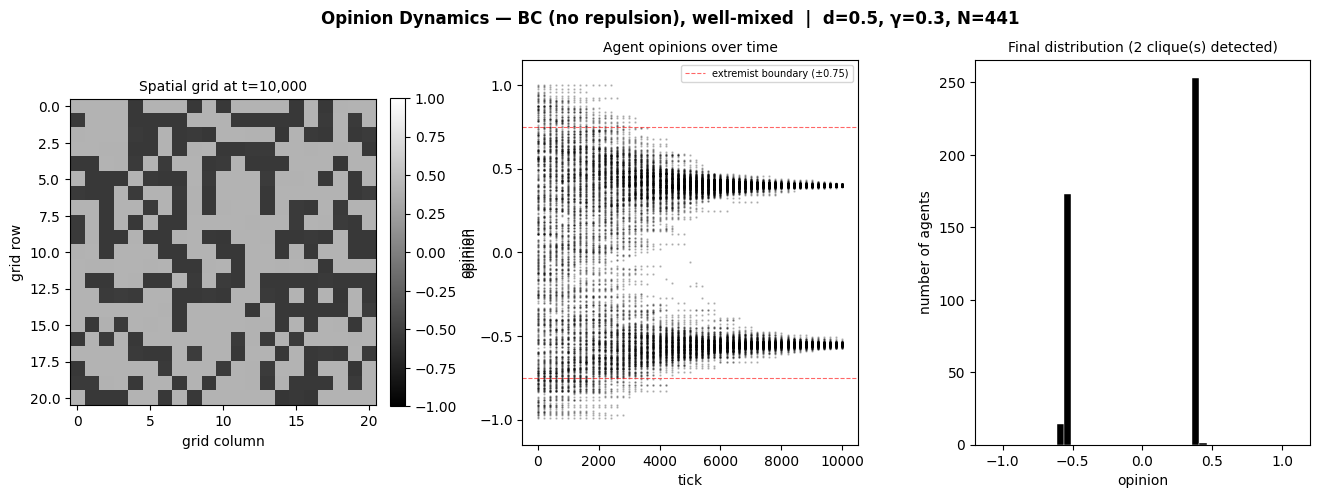

In [7]:
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

mode_label = "BC (no repulsion)" if not repulsion else "Negative Influence"
spatial_label = "spatial" if spatial_interactions else "well-mixed"
fig.suptitle(
    f"Opinion Dynamics — {mode_label}, {spatial_label}  "
    f"|  d={confidence_threshold}, γ={learning_rate}, N={N}",
    fontsize=12, fontweight='bold'
)

# ── PANEL 1: SPATIAL GRID ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
opinion_grid = ops_test.reshape(L, L)   # local: reshape for 2D display

im = ax1.imshow(opinion_grid, cmap='gray', vmin=-1, vmax=1,
                interpolation='nearest', aspect='equal')
ax1.set_title(f"Spatial grid at t={n_ticks:,}", fontsize=10)
ax1.set_xlabel("grid column")
ax1.set_ylabel("grid row")
plt.colorbar(im, ax=ax1, label='opinion', fraction=0.046, pad=0.04)

# ── PANEL 2: SCATTERPLOT — OPINIONS OVER TIME ────────────────────────────────
ax2 = fig.add_subplot(gs[1])

hist_ticks    = [h[0] for h in history_test]   # local
hist_opinions = [h[2] for h in history_test]   # local

ax2.scatter(hist_ticks, hist_opinions, s=0.4, alpha=0.25, color='black')
ax2.set_title("Agent opinions over time", fontsize=10)
ax2.set_xlabel("tick")
ax2.set_ylabel("opinion")
ax2.set_ylim(-1.15, 1.15)

# Draw horizontal dashed lines at ±(1 - d/2) to mark the extremist boundary
extremist_bound = 1 - 0.5 * confidence_threshold   # local
ax2.axhline( extremist_bound, color='red', linewidth=0.8, linestyle='--', alpha=0.6,
             label=f'extremist boundary (±{extremist_bound:.2f})')
ax2.axhline(-extremist_bound, color='red', linewidth=0.8, linestyle='--', alpha=0.6)
ax2.legend(fontsize=7)

# ── PANEL 3: HISTOGRAM — FINAL DISTRIBUTION ──────────────────────────────────
ax3 = fig.add_subplot(gs[2])

ax3.hist(ops_test, bins=40, range=(-1.02, 1.02), color='black',
         edgecolor='white', linewidth=0.3)
ax3.set_title(f"Final distribution ({n_cliques_test} clique(s) detected)", fontsize=10)
ax3.set_xlabel("opinion")
ax3.set_ylabel("number of agents")
ax3.set_xlim(-1.2, 1.2)

plt.show()


---
## 8. Initial vs. Final Opinion — Path Dependency (Figure 5.4B)

This plot reproduces Figure 5.4B from the book. Each point represents one agent,
with its initial opinion on the x-axis and its final opinion on the y-axis.

**What to look for:**
- Points cluster along a few horizontal bands — each band is one clique
- The correlation between initial and final opinion is strong but imperfect
- Agents that started near the same initial opinion can end up in different cliques
  (same x-value, different y-value) — this is **path dependency**: two agents with
  nearly identical starting opinions can be separated by early stochastic interactions
  that place them on different trajectories before cliques stabilize


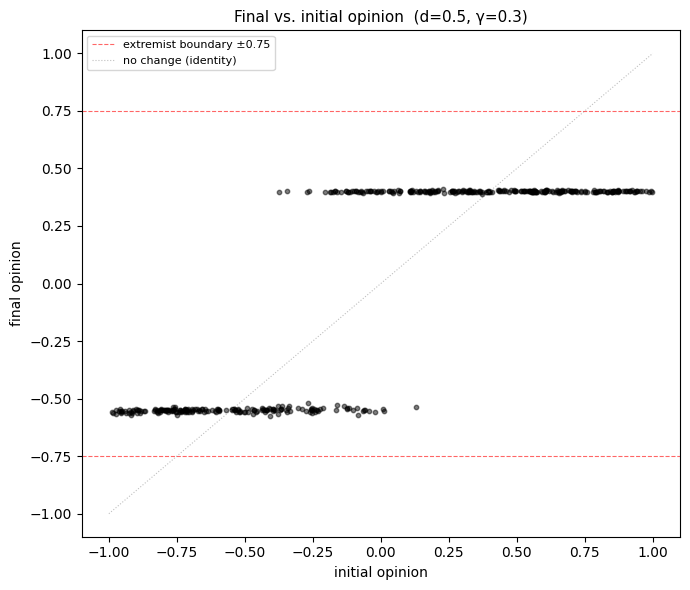

In [8]:
fig2, ax = plt.subplots(figsize=(7, 6))

ax.scatter(init_ops_test, ops_test, s=10, alpha=0.5, color='black')

# Reference lines at ±(1 - d/2): the extremist boundaries
extremist_bound = 1 - 0.5 * confidence_threshold
ax.axhline( extremist_bound, color='red', linewidth=0.8, linestyle='--',
            alpha=0.6, label=f'extremist boundary ±{extremist_bound:.2f}')
ax.axhline(-extremist_bound, color='red', linewidth=0.8, linestyle='--', alpha=0.6)

# Identity line: if final opinion = initial opinion (no change at all)
x_range = np.linspace(-1, 1, 100)
ax.plot(x_range, x_range, color='gray', linewidth=0.8, linestyle=':',
        alpha=0.5, label='no change (identity)')

ax.set_title(f"Final vs. initial opinion  (d={confidence_threshold}, γ={learning_rate})",
             fontsize=11)
ax.set_xlabel("initial opinion")
ax.set_ylabel("final opinion")
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## 9. Batch Experiment: Cliques vs. Confidence Threshold (Figure 5.4A)

This replicates the batch experiment from the book. We sweep the confidence threshold
`d` from 0.05 to 0.5, running 30 replications per value, and record the number of
emergent cliques. The run length matches the book: 80,000 ticks with γ = 0.5.

**Expected result:** as `d` increases, the number of cliques decreases. For large `d`
(close to 1), nearly everyone is within each other's threshold and consensus is reached
(1 clique). For small `d`, only very similar agents interact and many small clusters form.

> ⚠️ This cell runs 30 × 46 = 1,380 simulations. Each is short (80,000 ticks with
> efficient NumPy operations), but the full sweep may take a few minutes.
> Reduce `n_reps` or narrow `d_values` if you want a faster preview.


In [9]:
# ── BATCH EXPERIMENT PARAMETERS ─────────────────────────────────────────────

# Matching the book's experiment exactly (from the XML experiment block in the code)
d_values  = np.arange(0.05, 0.51, 0.01)   # global parameter sweep: 46 values
n_reps    = 30                             # replications per d value (global)
batch_ticks  = 80_000                      # long enough for cliques to stabilize
batch_gamma  = 0.5                         # γ = 0.5 as in the book's experiment

print(f"Sweeping d from {d_values[0]:.2f} to {d_values[-1]:.2f}")
print(f"  {len(d_values)} values × {n_reps} reps = {len(d_values)*n_reps:,} simulations")
print(f"  Each run: {batch_ticks:,} ticks,  γ={batch_gamma}")
print()

# ── RUN BATCH ────────────────────────────────────────────────────────────────

# results[d_val] = list of clique counts across all reps
results = {d_val: [] for d_val in d_values}   # local: collector dict

for rep in tqdm(range(n_reps), desc="Replications"):
    for d_val in d_values:
        # Fresh initialization for every combination of rep and d
        ops_batch, _, nbr_batch = initialize(L, seed=rep * 1000 + int(d_val * 100))
        
        # Run simulation (well-mixed BC model, no repulsion — matching the book)
        _, _ = run_simulation(
            ops_batch, nbr_batch,
            gamma=batch_gamma, d=d_val,
            n_ticks=batch_ticks, record_every=batch_ticks + 1,  # never snapshot
            spatial_interactions=False, repulsion=False,
            seed=rep
        )
        
        # Count cliques at the end of this run
        c = count_cliques(ops_batch, d_val)   # local: clique count for this run
        results[d_val].append(c)

print("Batch complete!")


Sweeping d from 0.05 to 0.50
  46 values × 30 reps = 1,380 simulations
  Each run: 80,000 ticks,  γ=0.5



Replications:   0%|          | 0/30 [00:00<?, ?it/s]

Batch complete!


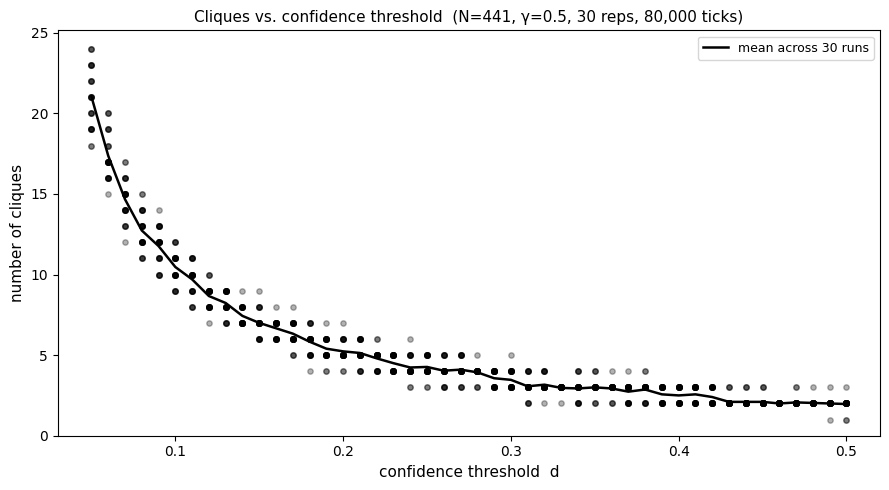

In [12]:
# ── PLOT RESULTS (Figure 5.4A) ───────────────────────────────────────────────

fig3, ax = plt.subplots(figsize=(9, 5))

# Individual run results (open circles, slightly transparent)
for d_val in d_values:
    ax.scatter(
        [d_val] * n_reps, results[d_val],
        s=15, alpha=0.3, color='black', zorder=2
    )

# Mean across replications (solid line connecting means)
means = [np.mean(results[d_val]) for d_val in d_values]   # local
ax.plot(d_values, means, color='black', linewidth=1.8, zorder=3,
        label='mean across 30 runs')

ax.set_title(
    f"Cliques vs. confidence threshold  (N={N}, γ={batch_gamma}, {n_reps} reps, "
    f"{batch_ticks:,} ticks)",
    fontsize=11
)
ax.set_xlabel("confidence threshold  d", fontsize=11)
ax.set_ylabel("number of cliques", fontsize=11)
ax.set_xlim(0.03, 0.52)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()



---
## 10. Negative Influence Model — Demonstration

Now we switch on `repulsion=True` to activate Equation 5.3. The confidence threshold
still determines the boundary between positive and negative influence, but instead of
ignoring each other, sufficiently different agents now push each other apart.

**Key prediction:** polarization is the only stable equilibrium.  
Regardless of `d`, all agents should eventually converge to $\pm 1$.

Try different values of `d` in the parameter cell below and re-run:
- `d = 0.9` → mostly positive influence; slow drift toward extremes driven by rare
  extremist interactions
- `d = 0.8` → rapid polarization
- `d = 0.2` → turbulent path (agents pushed in both directions) but eventual polarization


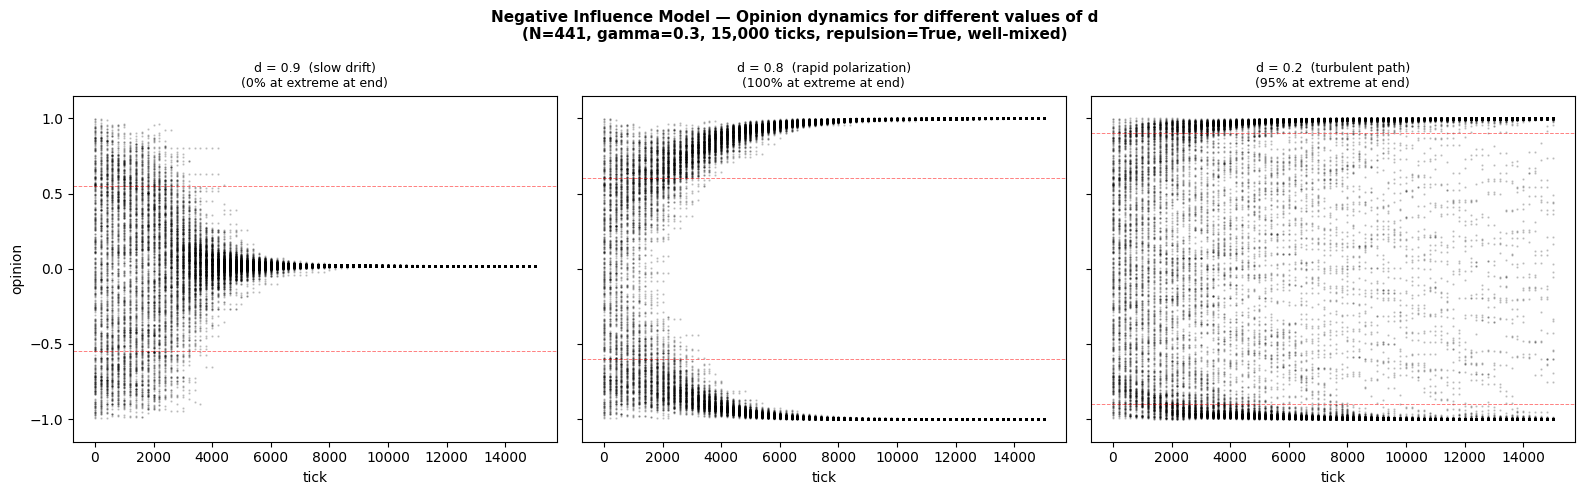

In [14]:
# ── PARAMETERS FOR THIS DEMO ─────────────────────────────────────────────────
# Change these and re-run the cells below to explore
d_neg         = 0.8     # confidence threshold for the negative influence demo
n_ticks_neg   = 15_000  # longer run to see full polarization
gamma_neg     = 0.3

# ── RUN THREE COMPARISON CONDITIONS ─────────────────────────────────────────
conditions = [
    {"d": 0.9, "label": "d = 0.9  (slow drift)"},
    {"d": 0.8, "label": "d = 0.8  (rapid polarization)"},
    {"d": 0.2, "label": "d = 0.2  (turbulent path)"},
]

fig4, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig4.suptitle(
    f"Negative Influence Model — Opinion dynamics for different values of d\n"
    f"(N={N}, gamma={gamma_neg}, {n_ticks_neg:,} ticks, repulsion=True, well-mixed)",
    fontsize=11, fontweight='bold'
)

for ax, cond in zip(axes, conditions):
    # Fresh initialization (same seed so initial conditions are identical across d)
    ops_neg, _, nbr_neg = initialize(L, seed=42)
    
    hist_neg, _ = run_simulation(
        ops_neg, nbr_neg,
        gamma=gamma_neg, d=cond["d"],
        n_ticks=n_ticks_neg, record_every=200,
        spatial_interactions=False, repulsion=True,
        seed=42
    )
    
    # Unpack history for scatterplot
    t_neg   = [h[0] for h in hist_neg]   # local
    op_neg  = [h[2] for h in hist_neg]   # local
    
    ax.scatter(t_neg, op_neg, s=0.4, alpha=0.2, color='black')
    ax.set_xlabel("tick")
    ax.set_ylim(-1.15, 1.15)
    
    # Mark the extremist boundaries for this d
    eb = 1 - 0.5 * cond["d"]
    ax.axhline( eb, color='red', linewidth=0.7, linestyle='--', alpha=0.5)
    ax.axhline(-eb, color='red', linewidth=0.7, linestyle='--', alpha=0.5)
    
    final_pct_extreme = np.mean(np.abs(ops_neg) > 0.9) * 100   # local
    ax.set_title(f"{cond['label']}\n({final_pct_extreme:.0f}% at extreme at end)",
                 fontsize=9)

axes[0].set_ylabel("opinion")
plt.tight_layout()
plt.show()

---
## 11. Summary and Key Takeaways

### What the models showed

| Model | Mechanism | Result |
|---|---|---|
| Bounded Confidence (repulsion=False) | Ignore agents beyond threshold `d` | Stable cliques; number of cliques increases as `d` decreases |
| Negative Influence (repulsion=True) | Push agents beyond threshold apart | Inevitable polarization; speed depends on `d` |

### Key conceptual points

**On bounded confidence:**
- Consensus is no longer inevitable — persistent disagreement can exist even when
  all influence is positive
- Path dependency means two agents with nearly identical starting opinions can end
  up in completely different cliques, depending on early random interactions
- The confidence threshold `d` is the key lever: smaller `d` → more cliques → more
  fragmentation

**On negative influence:**
- Polarization is the *only* stable equilibrium — there is no value of `d` that
  prevents it, only values that slow it down
- The turbulent dynamics at low `d` (agents pushed in both directions simultaneously)
  eventually resolve to the same extreme polarization as any other value of `d`

**On spatial interactions:**
- Spatial structure slows convergence (opinions must percolate through local channels)
- For BC: produces one dominant cluster plus small isolated factions (more diverse
  than the well-mixed model)
- For negative influence: produces geographic demographic zones

### Variable type reference

| Variable | Type | Role |
|---|---|---|
| `opinions` | Agent variable | Each agent's current opinion |
| `initial_opinions` | Agent variable | Opinion at t=0 (for path dependency plot) |
| `L, N, learning_rate, confidence_threshold` | Global variables | Simulation-wide settings |
| `spatial_interactions, repulsion` | Global toggles | Switch between model variants |
| `neighbor_map` | Global structure | Precomputed spatial neighbor lists |
| `x1, x2, gap, i, j` | Local variables | Temporary values inside update functions |
